<a href="https://colab.research.google.com/github/hgkim-gnbeng/tunnel_fire_dynamics_book/blob/book_example/%EC%98%88%EC%A0%9C_3_5_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

단위 길이당 발열량 (W/m): 117.00 W/m
레이놀즈 수 (Re): 328806.58
마찰계수 (f): 0.01946
누셀트 수 (Nu): 600.77
열전달계수 (h): 7.92 W/m²·K
열저항 (R_th): 0.4204 m²·K/W
열전도도 (k_air): 0.026 W/m·K
열전도도 (k_wall): 1.700 W/m·K

위치별 온도 결과:
위치(m)	공기온도(°C)	벽체온도(°C)
----------------------------------------
0.0	31.00		26.19
100.0	29.53		25.16
200.0	28.28		24.29
300.0	27.22		23.54
400.0	26.31		22.91
500.0	25.53		22.37
600.0	24.87		21.91
700.0	24.31		21.51
800.0	23.83		21.18
900.0	23.43		20.89

출구 온도 (x = 1000.0 m): 23.08 °C
----------------------------------------


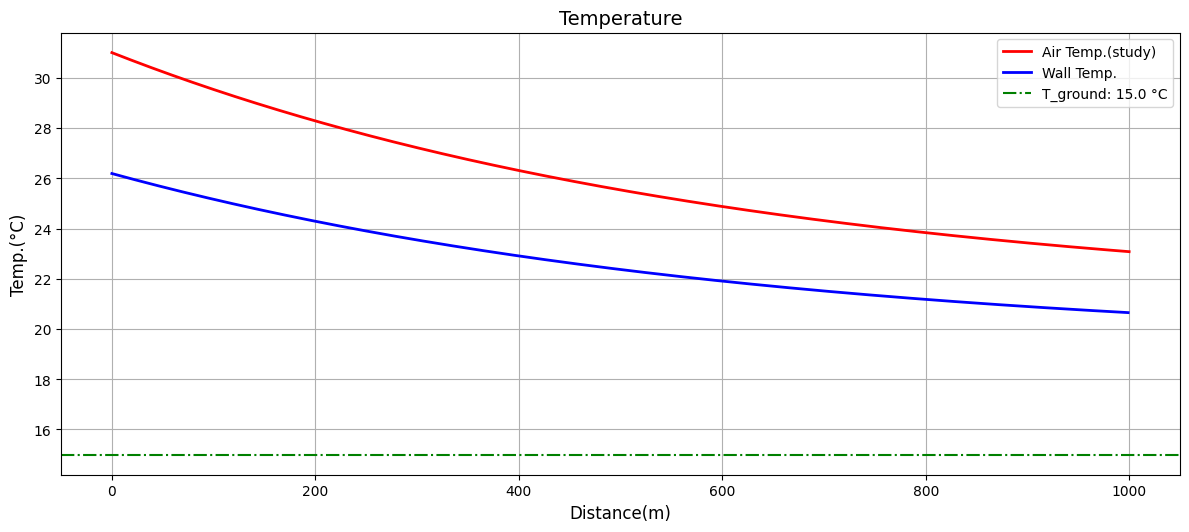

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# 입력 매개변수
L = 1000.0                 # 터널 길이 (m)
W = 1.7                    # 터널 폭 (m)
H = 2.35                    # 터널 높이 (m)
dx = 1.0                   # 공간 간격 (m)
q_gen = 117                # 단위 길이당 발열량 (W/m)
T_g = 15.0                 # 지중 온도 (°C)
T_inlet = 31.0             # 입구 공기 온도 (°C)
v = 2.5                    # 풍속 (m/s)
rho = 1.2                  # 공기 밀도 (kg/m³)
Cp = 1005.0                # 공기 비열 (J/kg·K)
k_air = 0.026              # 공기 열전도도 (W/m·K)
mu = 1.8e-5                # 공기 점성계수 (kg/m·s)
Pr = 0.71                  # 공기 프란틀 수
wall_thickness = 0.5       # 벽체 두께 (m)
k_wall = 1.7               # 콘크리트 열전도도 (W/m·K)

# Ref : 100 이상시 REF 참조 비교할 것 <단열조건 적용시>
print(f"단위 길이당 발열량 (W/m): {q_gen:.2f} W/m")

# 파생 매개변수
A_cross = W * H            # 단면적 (m²)
P_w = 2 * (W + H)          # 둘레 (m)
D_h = 4 * A_cross / P_w    # 수력직경 (m)
m_dot = rho * v * A_cross  # 질량유량 (kg/s)
N = int(L / dx) + 1        # 격자점 수

# 결과 배열
x = np.linspace(0, L, N)   # 위치 배열 (m)
T = np.zeros(N)            # 온도 배열 (°C)
T_wall = np.zeros(N-1)     # 벽체 온도 배열 (°C)
T[0] = T_inlet             # 초기 조건

# 레이놀즈 수 계산
Re = rho * v * D_h / mu
print(f"레이놀즈 수 (Re): {Re:.2f}")

# 마찰계수 계산
if Re < 2300:
    # 층류
    f = 64 / Re
else:
    # 난류 - Colebrook-White 방정식
    epsilon = 0.0015  # 콘크리트 거칠기 (m)

    def colebrook(f):
        return 1/np.sqrt(f) + 2*np.log10(epsilon/(3.7*D_h) + 2.51/(Re*np.sqrt(f)))

    f_initial_guess = 0.02
    f = fsolve(colebrook, f_initial_guess)[0]
print(f"마찰계수 (f): {f:.5f}")

# 누셀트 수 계산
if Re < 2300:
    # 층류
    Nu = 4.36  # 일정 열유속 조건
elif 2300 <= Re <= 5e6 and 0.5 <= Pr <= 2000:
    # Gnielinski 상관식
    Nu = ((f/8)*(Re-1000)*Pr) / (1.07 + 12.7*np.sqrt(f/8)*(Pr**(2/3)-1))
else:
    # Dittus-Boelter 상관식
    Nu = 0.023 * Re**0.8 * Pr**0.4  # 가열 조건

# 공기의 열전도도(W/m.K)
# Kannuluik와 Carman(1951)의 연구에 따르면, -183°C에서 218°C 사이의 공기 열전도도는 다음 식으로 표현됩니다: k_air = ( 5.75*10**-5 ) * ( 1 + 0.00317*T - 0.0000021**T )  #(W/m·K)

# 열전달계수 계산
h = Nu * k_air / D_h
print(f"누셀트 수 (Nu): {Nu:.2f}")
print(f"열전달계수 (h): {h:.2f} W/m²·K")

# 열저항 계산
R_th = 1/h + wall_thickness/k_wall
print(f"열저항 (R_th): {R_th:.4f} m²·K/W")

# 공기의 열전도도(W/m.K)
print(f"열전도도 (k_air): {k_air:.3f} W/m·K")

# 콘크리트 열전도도 (W/m·K)
print(f"열전도도 (k_wall): {k_wall:.3f} W/m·K")

# 온도분포 계산을 위한 반복 계산
for i in range(N-1):
    # 열전달 벽면적
    A_w = P_w * dx
    # 발열량
    q_c = q_gen * dx
    # T_i+1=[q_c + A_w/R_th*T_g + (m_dot*Cp-A_w/(2*R_th))*T_i] / [m_dot*Cp + A_w/(2*R_th)]
    numerator = q_c + (A_w / R_th) * T_g + (m_dot * Cp - A_w / (2 * R_th)) * T[i]
    denominator = m_dot * Cp + A_w / (2 * R_th)
    T[i+1] = numerator / denominator

    # T_w = [T_a + ((k_cond/ℓ)*R_th - 1)*T_g] / ((k_cond/ℓ)*R_th)
    T_avg = (T[i] + T[i+1]) / 2
    k_ratio = k_wall / wall_thickness
    T_wall[i] = (T_avg + (k_ratio * R_th - 1) * T_g) / (k_ratio * R_th)

# 선택 위치에서의 결과 출력
print("\n위치별 온도 결과:")
print("위치(m)\t공기온도(°C)\t벽체온도(°C)")
print("-" * 40)
step = max(1, int((N-1)/10))
for i in range(0, N-1, step):
    print(f"{x[i]:.1f}\t{T[i]:.2f}\t\t{T_wall[i]:.2f}")
print(f"\n출구 온도 (x = {L} m): {T[-1]:.2f} °C")
print("-" * 40)

# 그래프 출력
plt.figure(figsize=(12, 10))

# 온도 분포
plt.subplot(2, 1, 1)
plt.plot(x, T, 'r-', linewidth=2, label='Air Temp.(study)')
plt.plot(x[:-1], T_wall, 'b-', linewidth=2, label='Wall Temp.')
plt.axhline(y=T_g, color='g', linestyle='-.', label=f'T_ground: {T_g} °C')
plt.grid(True)
plt.xlabel('Distance(m)', fontsize=12)
plt.ylabel('Temp.(°C)', fontsize=12)
plt.title('Temperature', fontsize=14)
plt.legend()

plt.tight_layout()
plt.show()